# Learned emulator — assembling a target shape (JAX / Equinox)

This tutorial trains a **Graph Network Simulator (GNS)** to *assemble* one shape
into another. Starting from a point cloud sampled on a **source** mesh (an
armadillo), we learn a per-step update rule that deforms it into a **target**
mesh (the Stanford bunny). It is the **inverse / learning** counterpart to the
[forward simulator](forward_simulator) tutorial: instead of hand-specifying
mechanochemical rules, we *learn* them from a shape-matching objective, with
gradients flowing through the differentiable Warp physics.

Along the way you will:

1. sample point clouds from a source and a target mesh,
2. initialise per-particle state (position, radius, polarity, gene / morphogen
   channels),
3. build a contact graph and a GNS that predicts position, polarity and gene
   updates,
4. train it end-to-end with an optimal-transport (Sinkhorn) shape loss, and
5. visualise the learned assembly trajectory.

waxMorph ships this pipeline twice, at parity. This notebook uses the
**JAX / Equinox** backend; the [PyTorch version](learned_emulator) notebook runs the
identical workflow on the other backend. Comparing the two is the easiest way to
see the differences described in the
[architecture explanation](../explanation/architecture).

```{admonition} Runtime
:class: tip
This is a deliberately *tutorial-scale* run (1000 particles, a
50-step rollout, 600 epochs) chosen to finish in a
few minutes on a single GPU. Increase ``N_POINTS``, ``t_rollout`` and
``n_epochs`` for a sharper match.
```

## 0. Setup

We quiet XLA's compile logs and render off-screen so the figures embed as static images.

In [1]:
import os
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")  # quiet XLA compile logs

import numpy as np
import matplotlib.pyplot as plt

import pyglet
pyglet.options["headless"] = True
import pyvista as pv
pv.OFF_SCREEN = True

import warp as wp
import jax
import equinox as eqx
import optax

from waxmorph.render import PyVistaInterface

wp.init()
device = "cuda"
np.random.seed(42)
key = jax.random.PRNGKey(42)

# Tutorial-scale configuration.
N_POINTS = 1000
NUM_GENES = 16
T_ROLLOUT = 50
N_EPOCHS = 600

Warp 1.12.1 initialized:
   CUDA Toolkit 12.9, Driver 12.4
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA H100 PCIe" (79 GiB, sm_90, mempool enabled)
   Kernel cache:
     /insomnia001/home/ob2391/.cache/warp/1.12.1


In [2]:
def render_cloud(pos, radii, *, morph=None, polarities=None, title=None,
                 blim=-6.0, tlim=6.0, window_size=(720, 560)):
    """Render a particle cloud to an embedded PNG via an off-screen screenshot.

    We render statically (rather than as an interactive widget) so the figure
    embeds reliably in the built HTML docs.
    """
    n = len(pos)
    if morph is None:
        morph = np.full(n, 0.5, dtype=np.float32)
    if polarities is None:
        polarities = np.zeros((n, 3), dtype=np.float32)
        polarities[:, 2] = 1.0
    plotter = PyVistaInterface.draw_3d_view(
        pos, radii, morph, polarities, particle_count=n,
        blim=blim, tlim=tlim, alpha=0.9, show_polarities=False,
        theta_res=12, phi_res=8,
    )
    plotter.remove_bounds_axes()
    img = plotter.screenshot(return_img=True, window_size=window_size)
    plotter.close()
    fig, ax = plt.subplots(figsize=(window_size[0] / 120, window_size[1] / 120))
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title)
    plt.show()


def render_filmstrip(trajectory, radii, frames, *, blim=-6.0, tlim=6.0,
                     window_size=(360, 320)):
    """Screenshot several rollout frames and lay them out as a filmstrip."""
    shots = []
    n = len(radii)
    morph = np.full(n, 0.5, dtype=np.float32)
    pol = np.zeros((n, 3), dtype=np.float32)
    for f in frames:
        plotter = PyVistaInterface.draw_3d_view(
            trajectory[f], radii, morph, pol, particle_count=n,
            blim=blim, tlim=tlim, alpha=0.9, show_polarities=False,
            theta_res=10, phi_res=6,
        )
        plotter.remove_bounds_axes()
        shots.append((f, plotter.screenshot(return_img=True, window_size=window_size)))
        plotter.close()
    fig, axes = plt.subplots(1, len(shots), figsize=(3.0 * len(shots), 3.0))
    if len(shots) == 1:
        axes = [axes]
    for ax, (f, im) in zip(axes, shots):
        ax.imshow(im)
        ax.axis("off")
        ax.set_title(f"frame {f}")
    fig.suptitle("Learned assembly trajectory (source → target)", y=1.02)
    plt.tight_layout()
    plt.show()


## 1. Load meshes and sample point clouds

This is backend-agnostic: [`sample_mesh_pair`](../generated/waxmorph.data.sample_mesh_pair)
returns NumPy arrays.

In [3]:
from waxmorph.data import sample_mesh_pair

data = sample_mesh_pair(
    source_path="meshes/armadillo.ply",
    target_path="meshes/bunny.ply",
    n_points=N_POINTS,
    source_extent=14.29,
    target_extent=10.0,
)
print(f"source {data['source_pos'].shape}  target {data['target_pos'].shape}")
print(f"source radius {data['source_radius']:.4f}  "
      f"target radius {data['target_radius']:.4f}")

source (1000, 3)  target (1000, 3)
source radius 0.3630  target radius 0.3631


## 2. Initialise per-particle state

Identical to the PyTorch notebook — position, radius, unit polarity and gene
channels. See the [cell-state explanation](../explanation/cell_state).

In [4]:
N = len(data["source_pos"])
pos_np = data["source_pos"].copy()
rad_np = np.full(N, data["source_radius"], dtype=np.float32)

rng = np.random.default_rng(42)
pol_np = rng.standard_normal((N, 3)).astype(np.float32)
pol_np /= np.linalg.norm(pol_np, axis=-1, keepdims=True) + 1e-9
genes_np = rng.random((N, NUM_GENES)).astype(np.float32)

print(f"{N} particles, {NUM_GENES} gene channels")

1000 particles, 16 gene channels


### Source and target

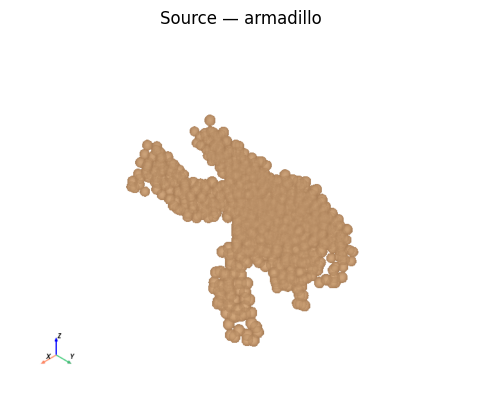

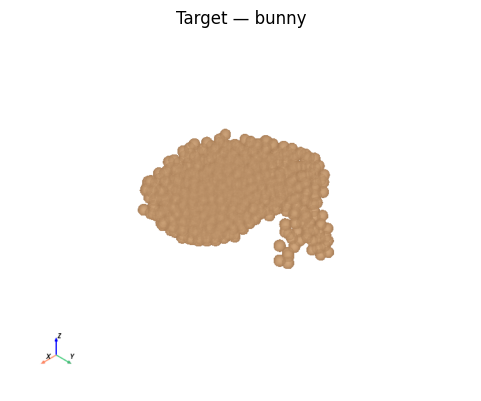

In [5]:
render_cloud(data["source_pos"], rad_np, title="Source — armadillo")
target_rad = np.full(len(data["target_pos"]), data["target_radius"], dtype=np.float32)
render_cloud(data["target_pos"], target_rad, title="Target — bunny")

## 3. Build the GNS

The JAX [`build_graph`](../generated/waxmorph.jax.graph.build_graph) returns a
**four**-tuple — the extra `num_edges` is the count of real edges inside a
fixed-size, padded edge buffer (static shapes are what let JAX compile the
rollout). The [`GNS`](../generated/waxmorph.jax.gnn.GNS) is an Equinox module, so
it takes an explicit PRNG `key` and the same `dX` / `dP` / `dc` heads.

In [6]:
from waxmorph.jax.graph import build_graph
from waxmorph.jax.gnn import GNS
from waxmorph.jax.losses import make_sinkhorn_loss

X_probe = wp.from_numpy(pos_np.copy(), dtype=wp.vec3f, device=device)
P_probe = wp.from_numpy(pol_np.copy(), dtype=wp.vec3f, device=device)
R_probe = wp.from_numpy(rad_np.copy(), dtype=wp.float32, device=device)
G_probe = wp.from_numpy(genes_np.copy(), dtype=wp.float32, device=device)

node_feats, edge_index, edge_feats, num_edges = build_graph(
    X_probe, P_probe, R_probe, particle_count=N, c=G_probe,
)
print(f"node features {node_feats.shape}")
print(f"edge index {edge_index.shape}  ({int(num_edges)} real directed edges)")
print(f"edge features {edge_feats.shape}")

model = GNS(
    node_feature_dim=int(node_feats.shape[1]),
    edge_feature_dim=int(edge_feats.shape[1]),
    node_latent_dim=256,
    edge_latent_dim=256,
    hidden_dim=256,
    num_mp_steps=5,
    num_mlp_layers=3,
    output_dims={"dX": 3, "dP": 3, "dc": NUM_GENES},
    checkpoint_processor=True,
    key=key,
)

n_params = sum(x.size for x in jax.tree_util.tree_leaves(eqx.filter(model, eqx.is_array)))
print(f"GNS parameters: {n_params:,}")

node features (1000, 16)
edge index (2, 4212)  (4212 real directed edges)
edge features (4212, 2)


GNS parameters: 3,631,638


The JAX shape loss is the debiased **Sinkhorn divergence** from `ott-jax`
([`make_sinkhorn_loss`](../generated/waxmorph.jax.losses.make_sinkhorn_loss); see
the [losses explanation](../explanation/losses)). Unlike
PyTorch, Optax optimisers are **stateless**, so we hold the optimiser state
(`opt_state`) explicitly and pass it to `train`.

```{admonition} Loss scale differs across backends
:class: note
The PyTorch (`geomloss`) and JAX (`ott-jax`) Sinkhorn implementations use
different internal scalings, so the *absolute* loss values are not directly
comparable between the two notebooks. The optimisation behaviour — a clearly
decreasing curve and a recognisable assembled shape — is what matches.
```

In [7]:
loss_fn = make_sinkhorn_loss(blur=0.05)
optimizer = optax.adamw(1e-3)
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

## 4. Train

[`train`](../generated/waxmorph.jax.train.train) has the same signature as the
PyTorch version apart from the explicit `opt_state`. The first epoch pays a
one-time XLA compilation cost; subsequent epochs are fast. As before, `targets`
supervises the final rollout frame (`t_rollout - 1`) against the bunny.

In [8]:
from waxmorph.jax.train import train, TrainConfig

config = TrainConfig(n_epochs=N_EPOCHS, t_rollout=T_ROLLOUT)
targets = [(config.t_rollout - 1, data["target_pos"])]

result = train(
    model, optimizer, opt_state, loss_fn,
    source_pos=data["source_pos"],
    polarities=pol_np,
    c=genes_np,
    radii=rad_np,
    targets=targets,
    config=config,
    device=device,
)
model = result.model

Module waxmorph.emulator abba15d load on device 'cuda:0' took 1222.22 ms  (compiled)


Module warp.jax_experimental.ffi 98d2031 load on device 'cuda:0' took 59.52 ms  (compiled)


Module waxmorph.jax.warp_autograd 3c963a5 load on device 'cuda:0' took 60.01 ms  (compiled)


Epoch   10/600  best=6.2761  shape=6.1696  l2=106.4535


Epoch   20/600  best=5.9285  shape=5.8045  l2=124.0334


...

Epoch  560/600  best=0.4178  shape=0.1236  l2=294.1715


Epoch  570/600  best=0.4071  shape=0.1357  l2=271.4453


Epoch  580/600  best=0.4071  shape=0.1357  l2=271.4453


Epoch  590/600  best=0.4035  shape=0.1088  l2=294.6307


Epoch  600/600  best=0.3930  shape=0.1210  l2=272.0270


## 5. Loss curves

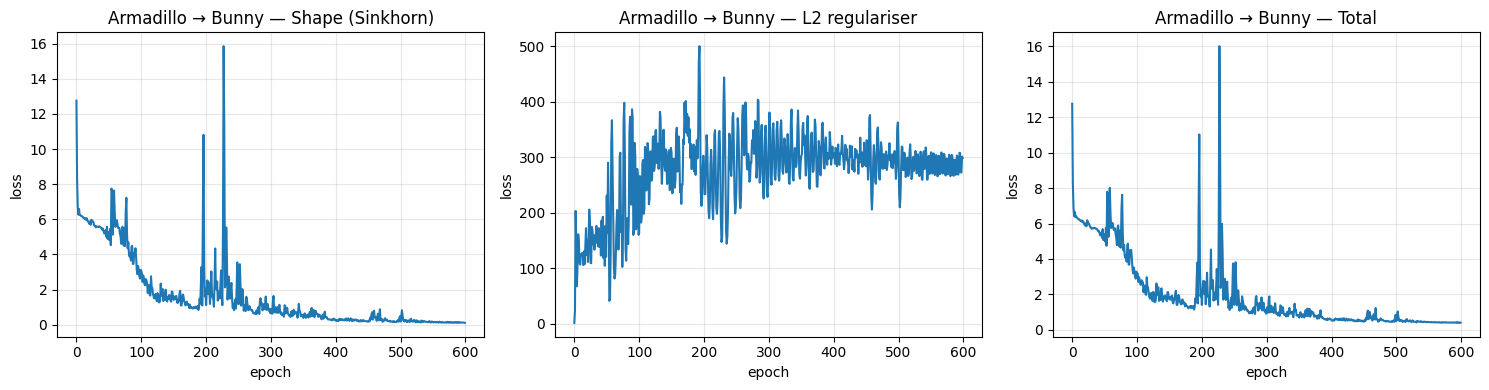

best total loss 0.3930 at epoch 597


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, key, title in zip(
    axes,
    ["losses_shape", "losses_l2", "losses_total"],
    ["Shape (Sinkhorn)", "L2 regulariser", "Total"],
):
    ax.plot(result.log[key])
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(f"Armadillo → Bunny — {title}")
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"best total loss {result.log['best_loss']:.4f} at epoch {result.log['best_epoch']}")

## 6. The learned assembly

`best_traj_pos` has shape `(t_rollout + 1, N, 3)`. We render the final frame and
a filmstrip of the trajectory.

trajectory (51, 1000, 3), best loss 0.3930


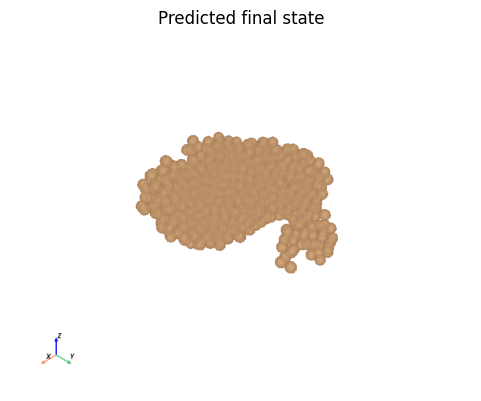

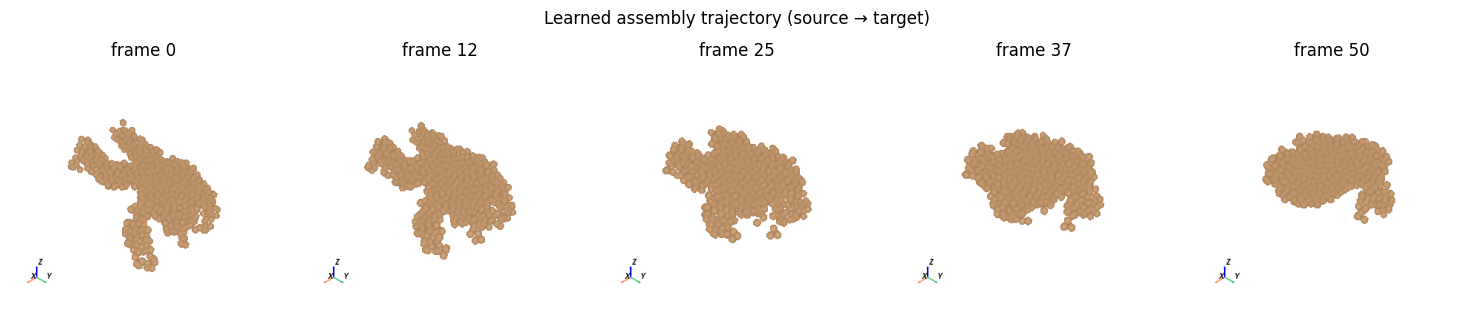

In [10]:
trajectory = np.asarray(result.log["best_traj_pos"])
print(f"trajectory {trajectory.shape}, best loss {result.log['best_loss']:.4f}")

render_cloud(trajectory[-1], rad_np, title="Predicted final state")
frames = np.linspace(0, trajectory.shape[0] - 1, 5).astype(int)
render_filmstrip(trajectory, rad_np, frames)

## 7. (Optional) Export a movie

[`WarpMovieRenderer`](../generated/waxmorph.render.WarpMovieRenderer) is
backend-agnostic and takes NumPy frames.

In [11]:
import os
from waxmorph.render import WarpMovieRenderer

os.makedirs("Output", exist_ok=True)
colors_rgb = np.full((N, 3), [0.3, 0.6, 0.9], dtype=np.float32)

with WarpMovieRenderer(
    filename="Output/armadillo_bunny_jax.usd",
    max_particles=N,
    backend="usd",
    fps=30,
    device=device,
) as mov:
    for f in range(trajectory.shape[0]):
        mov.write_frame_from_numpy(
            t=float(f) / 30.0,
            centers=trajectory[f],
            radii=rad_np,
            colors=colors_rgb,
            particle_count=N,
        )
print("wrote Output/armadillo_bunny_jax.usd")

Saved the USD stage file at `/insomnia001/depts/morpheus/users/ob2391/Waxmorph/Output/armadillo_bunny_jax.usd`
wrote Output/armadillo_bunny_jax.usd
